In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression

In [36]:
pd.__version__

'3.0.3'

In [37]:
# https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
df = pd.read_parquet('../data/green_tripdata_2026-01.parquet')
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40272 entries, 0 to 40271
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               40272 non-null  int32         
 1   lpep_pickup_datetime   40272 non-null  datetime64[us]
 2   lpep_dropoff_datetime  40272 non-null  datetime64[us]
 3   store_and_fwd_flag     34858 non-null  str           
 4   RatecodeID             34858 non-null  float64       
 5   PULocationID           40272 non-null  int32         
 6   DOLocationID           40272 non-null  int32         
 7   passenger_count        34858 non-null  float64       
 8   trip_distance          40272 non-null  float64       
 9   fare_amount            40272 non-null  float64       
 10  extra                  40272 non-null  float64       
 11  mta_tax                40272 non-null  float64       
 12  tip_amount             40272 non-null  float64       
 13  tolls_amount

In [39]:
df.lpep_dropoff_datetime - df.lpep_pickup_datetime 

0       0 days 00:27:18
1       0 days 00:48:23
2       0 days 00:21:18
3       0 days 00:16:12
4       0 days 00:18:36
              ...      
40267   0 days 00:15:00
40268   0 days 00:10:00
40269   0 days 00:25:59
40270   0 days 00:25:00
40271   0 days 00:35:30
Length: 40272, dtype: timedelta64[us]

In [40]:
df['duracion'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df['duracion'] = np.round(df['duracion'].dt.total_seconds()/60, 2)

In [41]:
# df = df[df['trip_type'] == 2]

<Axes: xlabel='duracion', ylabel='Count'>

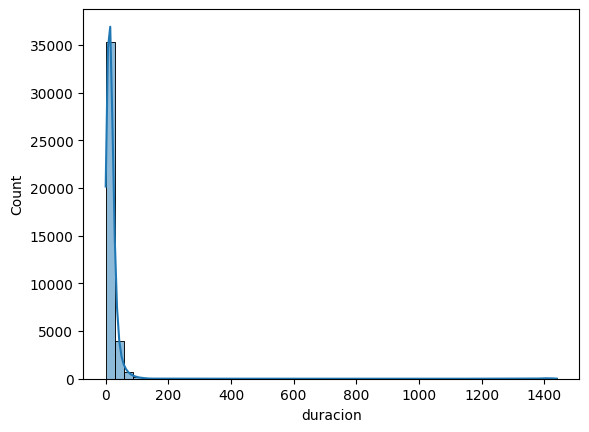

In [42]:
sns.histplot(df['duracion'], bins=50, kde=True)

In [43]:
df['duracion'].describe(percentiles = [0.95, 0.98, 0.99])

count    40272.000000
mean        20.075435
std         69.852128
min          0.000000
95%         44.020000
98%         64.287400
99%         82.885100
max       1439.800000
Name: duracion, dtype: float64

In [48]:
df = df[(df['duracion'] >= 1) & (df['duracion'] <= 60)]

In [49]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duracion
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75,27.30
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00,48.38
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00,21.30
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00,16.20
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00,18.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,NaN,NaN,25,228,NaN,2.57,17.98,...,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00,15.00
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,NaN,NaN,223,7,NaN,1.58,14.25,...,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00,10.00
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,NaN,NaN,256,228,NaN,8.17,3.00,...,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00,25.98
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,NaN,NaN,66,186,NaN,6.27,30.89,...,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75,25.00


In [50]:
categoricas = ['PULocationID', 'DOLocationID']
numericas = ['duracion']

In [62]:
df[categoricas] = df[categoricas].astype('str')

In [54]:
df[numericas].dtypes

duracion    float64
dtype: object

In [64]:
df.dtypes

VendorID                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag                  str
RatecodeID                      float64
PULocationID                        str
DOLocationID                        str
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
cbd_congestion_fee              float64
duracion                        float64
dtype: object

In [73]:
train_dicts = df[categoricas + numericas].to_dict(orient = 'records')

In [75]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [81]:
print(X_train.toarray())
print(dv.get_feature_names_out()[:10])

[[ 0.    0.    0.   ...  0.    0.   27.3 ]
 [ 0.    0.    0.   ...  0.    0.   48.38]
 [ 0.    0.    0.   ...  0.    0.   21.3 ]
 ...
 [ 0.    0.    0.   ...  0.    0.   25.98]
 [ 0.    0.    0.   ...  0.    0.   25.  ]
 [ 0.    0.    0.   ...  0.    0.   35.5 ]]
['DOLocationID=1' 'DOLocationID=10' 'DOLocationID=100' 'DOLocationID=101'
 'DOLocationID=102' 'DOLocationID=106' 'DOLocationID=107'
 'DOLocationID=108' 'DOLocationID=11' 'DOLocationID=112']


In [83]:
target = 'duracion'
y_train = df[target].values
y_train

array([27.3 , 48.38, 21.3 , ..., 25.98, 25.  , 35.5 ], shape=(38088,))

# Modelo